In [1]:
import polars as pl
import numpy as np
from scipy.sparse import coo_matrix
import umap

In [ ]:
ds = pl.scan_parquet(
    "/zata/zippy/kresgeb/nmf_stuff/dlPFC/data/batched_nmf/all_patterns_partitioned"
)
df = (
    ds.filter(pl.col("loading") > 0)
    .with_columns([pl.struct(["run_id", "pattern"]).hash().alias("pattern_uid")])
    .with_columns(
        [
            pl.col("pattern_uid").rank(method="dense").cast(pl.UInt32).alias("row_idx")
            - 1,  # needs to be 0-indexed
            pl.col("gene")
            .cast(pl.Categorical)  # convert to categorical
            .cast(pl.UInt32)  # convert category codes -> integer indices
            .alias("col_idx"),
        ]
    )
    .drop("pattern_uid")
    .collect()
)
print(df)

shape: (211_093_586, 10)
┌────────┬─────────┬────────┬──────────┬───┬─────┬─────┬─────────┬─────────┐
│ run_id ┆ pattern ┆ gene   ┆ loading  ┆ … ┆ L1  ┆ k   ┆ row_idx ┆ col_idx │
│ ---    ┆ ---     ┆ ---    ┆ ---      ┆   ┆ --- ┆ --- ┆ ---     ┆ ---     │
│ i32    ┆ i32     ┆ str    ┆ f64      ┆   ┆ f64 ┆ i64 ┆ u32     ┆ u32     │
╞════════╪═════════╪════════╪══════════╪═══╪═════╪═════╪═════════╪═════════╡
│ 1      ┆ 1       ┆ FBXL18 ┆ 0.000058 ┆ … ┆ 0.1 ┆ 10  ┆ 33670   ┆ 0       │
│ 1      ┆ 2       ┆ FBXL18 ┆ 0.000039 ┆ … ┆ 0.1 ┆ 10  ┆ 33366   ┆ 0       │
│ 1      ┆ 3       ┆ FBXL18 ┆ 0.000075 ┆ … ┆ 0.1 ┆ 10  ┆ 41064   ┆ 0       │
│ 1      ┆ 4       ┆ FBXL18 ┆ 0.000029 ┆ … ┆ 0.1 ┆ 10  ┆ 3570    ┆ 0       │
│ 1      ┆ 5       ┆ FBXL18 ┆ 0.000063 ┆ … ┆ 0.1 ┆ 10  ┆ 21630   ┆ 0       │
│ …      ┆ …       ┆ …      ┆ …        ┆ … ┆ …   ┆ …   ┆ …       ┆ …       │
│ 749    ┆ 53      ┆ DHRSX  ┆ 0.000061 ┆ … ┆ 0.7 ┆ 90  ┆ 31596   ┆ 10684   │
│ 749    ┆ 59      ┆ DHRSX  ┆ 0.000046 ┆ … ┆ 0.7 ┆ 

In [3]:
pattern_meta = (
    df.select(pl.exclude("gene", "loading", "col_idx")).unique().sort("row_idx")
)
gene_meta = df.select("gene", "col_idx").unique().sort("col_idx")
print(pattern_meta)
print(gene_meta)

shape: (41_250, 7)
┌────────┬─────────┬────────┬───────────┬─────┬─────┬─────────┐
│ run_id ┆ pattern ┆ seed   ┆ tol       ┆ L1  ┆ k   ┆ row_idx │
│ ---    ┆ ---     ┆ ---    ┆ ---       ┆ --- ┆ --- ┆ ---     │
│ i32    ┆ i32     ┆ i32    ┆ f64       ┆ f64 ┆ i64 ┆ u32     │
╞════════╪═════════╪════════╪═══════════╪═════╪═════╪═════════╡
│ 649    ┆ 64      ┆ 2025   ┆ 0.00001   ┆ 0.7 ┆ 90  ┆ 0       │
│ 452    ┆ 9       ┆ 42     ┆ 0.00001   ┆ 0.5 ┆ 20  ┆ 1       │
│ 640    ┆ 42      ┆ 120301 ┆ 0.00001   ┆ 0.7 ┆ 100 ┆ 2       │
│ 718    ┆ 2       ┆ 1029   ┆ 0.0000001 ┆ 0.7 ┆ 80  ┆ 3       │
│ 715    ┆ 50      ┆ 1029   ┆ 0.0000001 ┆ 0.7 ┆ 50  ┆ 4       │
│ …      ┆ …       ┆ …      ┆ …         ┆ …   ┆ …   ┆ …       │
│ 139    ┆ 25      ┆ 120301 ┆ 0.0000001 ┆ 0.1 ┆ 90  ┆ 41245   │
│ 269    ┆ 36      ┆ 1029   ┆ 0.0000001 ┆ 0.0 ┆ 90  ┆ 41246   │
│ 420    ┆ 49      ┆ 1029   ┆ 0.0000001 ┆ 0.2 ┆ 100 ┆ 41247   │
│ 388    ┆ 63      ┆ 120301 ┆ 0.000001  ┆ 0.2 ┆ 80  ┆ 41248   │
│ 275    ┆ 23      ┆ 

In [4]:
rows = df["row_idx"].to_numpy()
cols = df["col_idx"].to_numpy()
vals = df["loading"].to_numpy()

n_rows = int(rows.max()) + 1
n_cols = int(cols.max()) + 1

mat = coo_matrix((vals, (rows, cols)), shape=(n_rows, n_cols)).tocsr()
print(mat)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 211065934 stored elements and shape (41250, 34978)>
  Coords	Values
  (0, 385)	0.03527543237641608
  (0, 1610)	0.06340401462705621
  (0, 1679)	0.04414961625963279
  (0, 1963)	0.007353307893484654
  (0, 2315)	0.008209300138483299
  (0, 2771)	0.013397035261785128
  (0, 3158)	0.01694557216350994
  (0, 4238)	0.008527800388332915
  (0, 4484)	0.16741380845738932
  (0, 4830)	0.06384950266400204
  (0, 6771)	0.005975823513134125
  (0, 7770)	0.0012402015414140991
  (0, 7975)	0.0005343447808100523
  (0, 8094)	0.004892986811502506
  (0, 9948)	0.10936403750066433
  (0, 10850)	0.07718955795771366
  (0, 13606)	0.07255452814778364
  (0, 14601)	0.0025053247631701917
  (0, 14685)	0.2180172246969571
  (0, 14738)	0.004290548294765327
  (0, 15729)	0.05223535442623298
  (0, 16341)	0.02267467733575984
  (1, 1)	3.621385899235499e-05
  (1, 3)	8.287601284377682e-05
  (1, 9)	0.00041205687579947195
  :	:
  (41249, 34918)	1.517097425525881e-08
  (41249,

In [5]:
subset_pattern_meta = pattern_meta.sample(n=5000).sort("row_idx")
print(subset_pattern_meta)
subset_row_idx = subset_pattern_meta["row_idx"].to_numpy()
print(subset_row_idx)

shape: (5_000, 7)
┌────────┬─────────┬────────┬───────────┬─────┬─────┬─────────┐
│ run_id ┆ pattern ┆ seed   ┆ tol       ┆ L1  ┆ k   ┆ row_idx │
│ ---    ┆ ---     ┆ ---    ┆ ---       ┆ --- ┆ --- ┆ ---     │
│ i32    ┆ i32     ┆ i32    ┆ f64       ┆ f64 ┆ i64 ┆ u32     │
╞════════╪═════════╪════════╪═══════════╪═════╪═════╪═════════╡
│ 321    ┆ 10      ┆ 31415  ┆ 0.00001   ┆ 0.2 ┆ 10  ┆ 16      │
│ 466    ┆ 51      ┆ 1029   ┆ 0.00001   ┆ 0.5 ┆ 60  ┆ 18      │
│ 338    ┆ 71      ┆ 120301 ┆ 0.00001   ┆ 0.2 ┆ 80  ┆ 40      │
│ 176    ┆ 28      ┆ 31415  ┆ 0.00001   ┆ 0.0 ┆ 60  ┆ 52      │
│ 466    ┆ 17      ┆ 1029   ┆ 0.00001   ┆ 0.5 ┆ 60  ┆ 53      │
│ …      ┆ …       ┆ …      ┆ …         ┆ …   ┆ …   ┆ …       │
│ 422    ┆ 19      ┆ 31415  ┆ 0.0000001 ┆ 0.2 ┆ 20  ┆ 41225   │
│ 86     ┆ 2       ┆ 120301 ┆ 0.000001  ┆ 0.1 ┆ 60  ┆ 41226   │
│ 39     ┆ 53      ┆ 120301 ┆ 0.00001   ┆ 0.1 ┆ 90  ┆ 41228   │
│ 47     ┆ 28      ┆ 2025   ┆ 0.00001   ┆ 0.1 ┆ 70  ┆ 41234   │
│ 185    ┆ 7       ┆ 1

In [6]:
subset_mat = mat[subset_row_idx, :]
print(subset_mat)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 25520822 stored elements and shape (5000, 34978)>
  Coords	Values
  (0, 1)	0.00023343089618633428
  (0, 3)	0.00019399259145225724
  (0, 7)	2.639990045993123e-05
  (0, 8)	3.521503967889031e-05
  (0, 9)	1.170515582217e-05
  (0, 10)	8.693469493840523e-06
  (0, 16)	7.3480391036711456e-06
  (0, 19)	9.99722631662096e-05
  (0, 21)	3.43131232088924e-05
  (0, 23)	0.00023368018811903803
  (0, 24)	0.0005482890474734384
  (0, 25)	0.00010094362036984971
  (0, 26)	0.0010920612666689212
  (0, 27)	0.000907601573757466
  (0, 28)	6.560053982908429e-06
  (0, 29)	0.0004901258209099125
  (0, 30)	5.244872389896183e-05
  (0, 31)	0.000554236560282285
  (0, 32)	0.0001383875378292055
  (0, 38)	0.0003572365056523514
  (0, 39)	0.0005266610558374007
  (0, 42)	0.00019019031523940939
  (0, 43)	3.842383824264294e-05
  (0, 48)	0.0002302031454674413
  (0, 49)	0.0004857020017422126
  :	:
  (4999, 34919)	5.09077924867266e-07
  (4999, 34923)	4.931741166577614e-

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    n_jobs=64,  # for parallel (incompatible with random_state)
    # random_state=42,  # for reproducibility (incompatible with n_jobs)
    # verbose=True,
)

mapper = reducer.fit(subset_mat)

UMAP(angular_rp_forest=True, metric='cosine', n_jobs=64, verbose=True)
Tue Dec  2 14:33:35 2025 Construct fuzzy simplicial set
Tue Dec  2 14:33:36 2025 Finding Nearest Neighbors
Tue Dec  2 14:33:36 2025 Building RP forest with 9 trees
Tue Dec  2 14:34:35 2025 metric NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	 4  /  12
	Stopping threshold met -- exiting after 4 iterations
Tue Dec  2 14:35:01 2025 Finished Nearest Neighbor Search
Tue Dec  2 14:35:03 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Dec  2 14:35:06 2025 Finished embedding


Loading BokehJS ...

<Axes: >

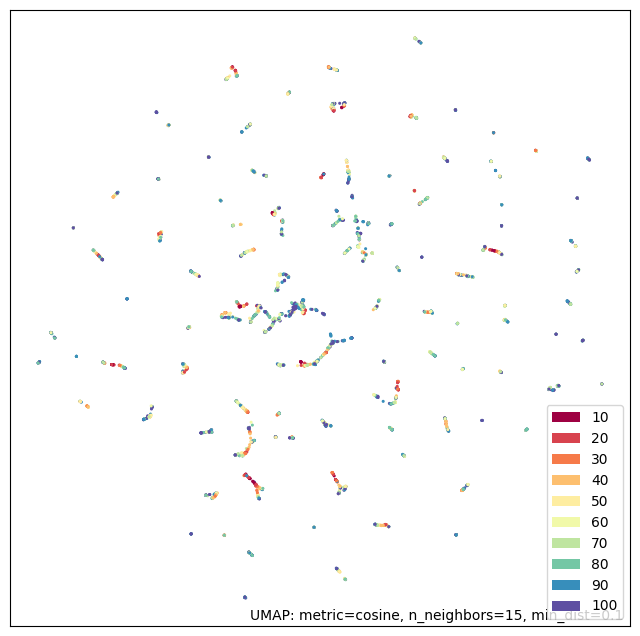

In [23]:
import umap.plot

umap.plot.output_notebook()
umap.plot.points(mapper, labels=subset_pattern_meta["k"])

In [ ]:
p = umap.plot.interactive(
    mapper,
    labels=subset_pattern_meta["k"],
    point_size=4,
    hover_data=subset_pattern_meta.to_pandas(),
)
umap.plot.show(p)

In [ ]:
embedding = mapper.embedding_
embedding_df = pl.DataFrame(
    {
        "row_idx": subset_row_idx,
        "UMAP1": embedding[:, 0],
        "UMAP2": embedding[:, 1],
    }
)

# save embedding with pattern metadata
embedding_df = subset_pattern_meta.join(embedding_df, on="row_idx", how="left")
# save to parquet
embedding_df.write_parquet(
    "/zata/zippy/kresgeb/nmf_stuff/dlPFC/output/nmf_umaps/umap_embeddings/umap_embeddings_and_meta.parquet",
    mkdir=True,
)
print(embedding_df)

shape: (5_000, 9)
┌────────┬─────────┬────────┬───────────┬───┬─────┬─────────┬────────────┬───────────┐
│ run_id ┆ pattern ┆ seed   ┆ tol       ┆ … ┆ k   ┆ row_idx ┆ UMAP1      ┆ UMAP2     │
│ ---    ┆ ---     ┆ ---    ┆ ---       ┆   ┆ --- ┆ ---     ┆ ---        ┆ ---       │
│ i32    ┆ i32     ┆ i32    ┆ f64       ┆   ┆ i64 ┆ u32     ┆ f32        ┆ f32       │
╞════════╪═════════╪════════╪═══════════╪═══╪═════╪═════════╪════════════╪═══════════╡
│ 321    ┆ 10      ┆ 31415  ┆ 0.00001   ┆ … ┆ 10  ┆ 16      ┆ 2.151829   ┆ 18.254854 │
│ 466    ┆ 51      ┆ 1029   ┆ 0.00001   ┆ … ┆ 60  ┆ 18      ┆ -1.146499  ┆ 19.714708 │
│ 338    ┆ 71      ┆ 120301 ┆ 0.00001   ┆ … ┆ 80  ┆ 40      ┆ -7.093369  ┆ -6.636581 │
│ 176    ┆ 28      ┆ 31415  ┆ 0.00001   ┆ … ┆ 60  ┆ 52      ┆ 3.19324    ┆ 13.630595 │
│ 466    ┆ 17      ┆ 1029   ┆ 0.00001   ┆ … ┆ 60  ┆ 53      ┆ -14.905165 ┆ -1.280188 │
│ …      ┆ …       ┆ …      ┆ …         ┆ … ┆ …   ┆ …       ┆ …          ┆ …         │
│ 422    ┆ 19      ┆ 3141

In [11]:
from sklearn.manifold import trustworthiness

trust = trustworthiness(subset_mat, embedding, n_neighbors=15)
print("Trustworthiness:", trust)

Trustworthiness: 0.9572891407139509


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool, CustomJS, TextInput
from bokeh.layouts import column
from bokeh.transform import linear_cmap
import bokeh


def interactive_from_embeddings(
    embedding,
    labels=None,
    values=None,
    hover_data=None,
    cmap="Blues",
    color_key_cmap="Spectral",
    background="white",
    width=800,
    height=800,
    point_size=None,
    tools=None,
    alpha=None,
):
    """
    Create an interactive Bokeh plot directly from 2D embeddings
    WITHOUT requiring a UMAP model object.
    """

    embedding = np.asarray(embedding)
    if embedding.shape[1] != 2:
        raise ValueError("Embedding must be of shape (n_samples, 2)")

    n = embedding.shape[0]
    if point_size is None:
        point_size = 100.0 / np.sqrt(n)

    df = pd.DataFrame(
        {
            "x": embedding[:, 0],
            "y": embedding[:, 1],
        }
    )

    # ----- Coloring logic (labels OR values OR constant) -----

    if labels is not None and values is not None:
        raise ValueError("Choose only one of labels or values")

    if labels is not None:
        df["label"] = labels
        unique_labels = np.unique(labels)
        cmap_obj = plt.get_cmap(color_key_cmap)
        palette = [
            bokeh.colors.RGB(*[int(c * 255) for c in cmap_obj(i)[:3]]).to_hex()
            for i in np.linspace(0, 1, len(unique_labels))
        ]
        color_map = dict(zip(unique_labels, palette))
        df["color"] = pd.Series(labels).map(color_map)

        color_spec = "color"

    elif values is not None:
        df["value"] = values
        cmap_obj = plt.get_cmap(cmap)
        palette = [
            bokeh.colors.RGB(*[int(c * 255) for c in cmap_obj(i)[:3]]).to_hex()
            for i in np.linspace(0, 1, 256)
        ]

        color_spec = linear_cmap(
            field_name="value",
            palette=palette,
            low=np.min(values),
            high=np.max(values),
        )

    else:
        # single mid-color
        color_spec = plt.get_cmap(cmap)(0.5)
        color_spec = bokeh.colors.RGB(
            int(color_spec[0] * 255),
            int(color_spec[1] * 255),
            int(color_spec[2] * 255),
        ).to_hex()

    # hover_data columns
    if hover_data is not None:
        for col in hover_data.columns:
            df[col] = hover_data[col]

    # alpha channel
    if alpha is None:
        df["alpha"] = 1.0
    else:
        df["alpha"] = alpha

    source = ColumnDataSource(df)

    # ----- Create Bokeh figure -----

    fig = figure(
        width=width,
        height=height,
        background_fill_color=background,
        tools=tools if tools is not None else "pan,wheel_zoom,box_zoom,save,reset,help",
        tooltips=[
            (col, f"@{{{col}}}")
            for col in (hover_data.columns if hover_data is not None else [])
        ],
    )

    fig.scatter(
        x="x",
        y="y",
        source=source,
        color=color_spec,
        size=point_size,
        alpha="alpha",
    )

    fig.grid.visible = False
    fig.axis.visible = False

    return fig

In [19]:
from bokeh.io import show
from bokeh.plotting import figure

plot = interactive_from_embeddings(
    embedding_df[["UMAP1", "UMAP2"]].to_numpy(),
    labels=embedding_df["pattern"],
    hover_data=embedding_df.drop("UMAP1", "UMAP2"),
    point_size=4,
)

show(plot)

In [20]:
prev_umap = pl.scan_parquet("/zata/zippy/kresgeb/nmf_stuff/dlPFC/output/nmf_umaps/umap_embeddings/first_save.parquet").collect()

print(prev_umap)

shape: (41_250, 9)
┌────────┬─────────┬────────┬───────────┬───┬─────┬─────────┬───────────┬───────────┐
│ run_id ┆ pattern ┆ seed   ┆ tol       ┆ … ┆ k   ┆ row_idx ┆ UMAP1     ┆ UMAP2     │
│ ---    ┆ ---     ┆ ---    ┆ ---       ┆   ┆ --- ┆ ---     ┆ ---       ┆ ---       │
│ i32    ┆ i32     ┆ i32    ┆ f64       ┆   ┆ i64 ┆ u32     ┆ f32       ┆ f32       │
╞════════╪═════════╪════════╪═══════════╪═══╪═════╪═════════╪═══════════╪═══════════╡
│ 649    ┆ 64      ┆ 2025   ┆ 0.00001   ┆ … ┆ 90  ┆ 0       ┆ 10.672416 ┆ 7.081692  │
│ 452    ┆ 9       ┆ 42     ┆ 0.00001   ┆ … ┆ 20  ┆ 1       ┆ 5.647392  ┆ -1.078495 │
│ 640    ┆ 42      ┆ 120301 ┆ 0.00001   ┆ … ┆ 100 ┆ 2       ┆ 7.034378  ┆ 11.608908 │
│ 718    ┆ 2       ┆ 1029   ┆ 0.0000001 ┆ … ┆ 80  ┆ 3       ┆ -0.695964 ┆ 10.093839 │
│ 715    ┆ 50      ┆ 1029   ┆ 0.0000001 ┆ … ┆ 50  ┆ 4       ┆ 14.760114 ┆ 15.162823 │
│ …      ┆ …       ┆ …      ┆ …         ┆ … ┆ …   ┆ …       ┆ …         ┆ …         │
│ 139    ┆ 25      ┆ 120301 ┆ 0.000

In [22]:
plot = interactive_from_embeddings(
    prev_umap[["UMAP1", "UMAP2"]].to_numpy(),
    labels=prev_umap["k"],
    hover_data=prev_umap.drop("UMAP1", "UMAP2"),
    point_size=4,
)

show(plot)